In [1]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 - Load Dataset
df = pd.read_csv('../data/train.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

In [3]:
# Cell 3 - Explore the Data
print("Total rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values in each column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total rows and columns: (1460, 81)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch'

In [4]:
# Cell 4 - Clean the Data

# Drop columns with too many missing values
df = df.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'])

# Fill missing numbers with average
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

# Fill missing text columns with 'None'
for col in ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
            'BsmtFinType1', 'BsmtFinType2', 'GarageType', 
            'GarageFinish', 'GarageQual', 'GarageCond', 'Electrical']:
    df[col] = df[col].fillna('None')

print("Data cleaned!")
print("Missing values remaining:", df.isnull().sum().sum())

Data cleaned!
Missing values remaining: 0


In [5]:
# Cell 5 - Prepare Data for Training

# Separate features (X) and target (y)
X = df.drop(columns=['Id', 'SalePrice'])
y = df['SalePrice']

# Convert text columns to numbers
X = pd.get_dummies(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample prices:")
print(y.head())

Features shape: (1460, 280)
Target shape: (1460,)

Sample prices:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [6]:
# Cell 6 - Train the Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
predictions = model.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model trained successfully!")
print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R2 Score: {r2:.4f}")

Model trained successfully!
Mean Absolute Error: $17,498
R2 Score: 0.8942


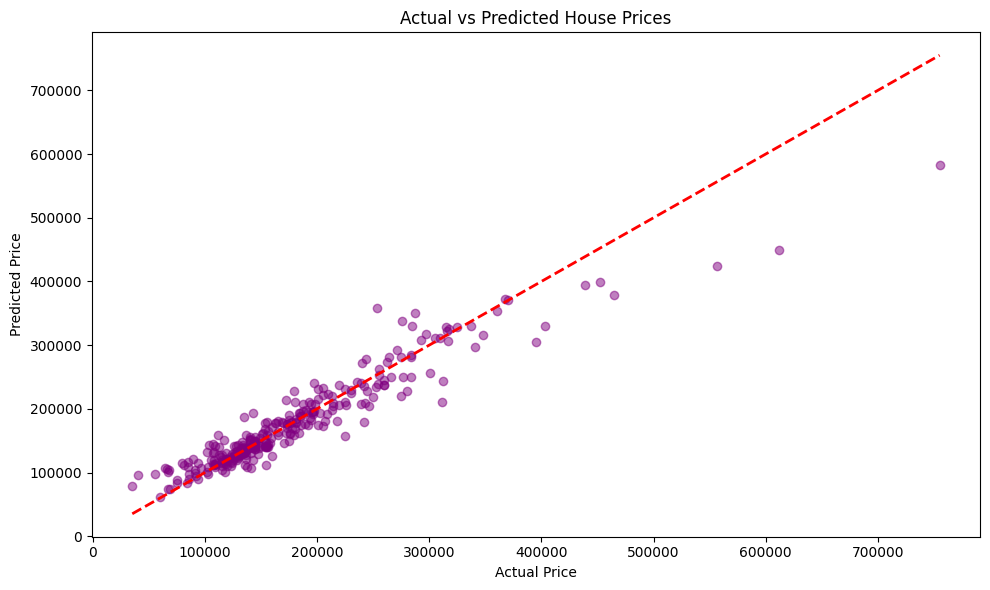

In [7]:
# Cell 7 - Visualize Results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 - Save the Model
import joblib
import os

# Create model folder if it doesn't exist
os.makedirs('../model', exist_ok=True)

# Save the model
joblib.dump(model, '../model/house_model.pkl')

# Save the feature columns too (we will need this later)
joblib.dump(X.columns.tolist(), '../model/feature_columns.pkl')

print("Model saved successfully!")
print("Location: ../model/house_model.pkl")

Model saved successfully!
Location: ../model/house_model.pkl
